# Optogenetic inhibition of mFC during route planning — supplementary analyses

Supplementary behavioural analyses accompanying the main opto figure: viral-expression anatomy, control-group performance, example trajectories, goal-resolved excess-steps breakdowns, trial-locked distance-to-goal dynamics, per-maze strategy fits, and movement-speed controls.

## Setup

Set the working directory, configure matplotlib defaults, and define the figure output path.

In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_opto-mFC/route_planning/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_opto-mFC/route_planning/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

from importlib import reload
import numpy as np

In [9]:
from pathlib import Path

SAVE_FIG_PATH = Path("../results/figures/supp")

## Anatomy of viral expression

Per-subject quantification of GtACR2 expression restricted to the fibre-tip illumination cone, broken down by frontal-cortex region.

In [6]:
from GridMaze.analysis.anatomy import blobs as ab

In [7]:
opto_anatomy_df = ab.get_opto_anatomy_df(condition="opto", verbose=False)

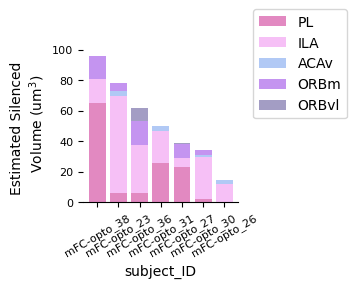

In [10]:
f, ax = plt.subplots(1, 1, figsize=(2, 2))
ab.plot_anatomy_summary(
    opto_anatomy_df,
    subject_order=[
        "mFC-opto_38",
        "mFC-opto_23",
        "mFC-opto_36",
        "mFC-opto_31",
        "mFC-opto_27",
        "mFC-opto_30",
        "mFC-opto_26",
    ],
    ax=ax,
)
f.savefig(SAVE_FIG_PATH / "anatomy_regions_summary.pdf")

## Control-group performance over days

Time course of the stim effect on excess steps in control mice, we note that it takes 4-5 days for animals to get used to navigated with the light on

In [11]:
from GridMaze.analysis.behaviour import performance_metrics as pm

In [12]:
performance_df = pm.get_performance_df()

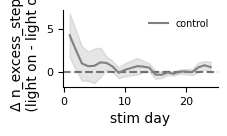

In [13]:
f, ax = plt.subplots(1, 1, figsize=(2, 1))
pm.plot_stim_effects_over_days(
    performance_df,
    y="n_excess_steps",
    groups=["control"],
    ax=ax,
)
f.savefig(SAVE_FIG_PATH / "control_excess_steps_over_days.pdf")

## Example trial trajectories

Time-coloured trajectories from individual trials of an opto subject, with stim epochs highlighted, illustrating single-trial behaviour during inhibition. 

In [14]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.behaviour import trajectory_plotting as tp

session = gs.get_maze_sessions(subject_IDs=["mFC-opto_23"], maze_names=["maze_2"], days_on_maze=[9])[0]

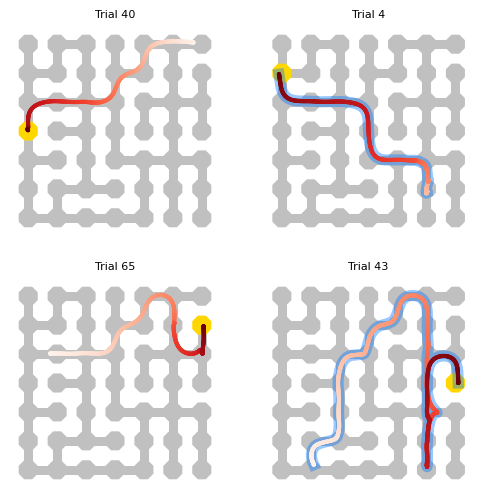

In [15]:
f, axes = plt.subplots(2, 2, figsize=(6, 6))
for ax, t in zip(axes.flatten(), [40, 4, 65, 43]):
    tp.plot_fancy_trial_trajectory(session, trial=t, ax=ax)
f.savefig(SAVE_FIG_PATH / "more_example_trials.pdf")

## Goal-resolved excess-steps analyses

Breakdown of stim-induced excess steps by goal location and by goal-graph properties.

In [ ]:
from GridMaze.analysis.behaviour import excess_steps as es

In [18]:
excess_steps_df = pm.get_performance_df()

### Per-goal excess-steps heatmaps

Mean excess steps per goal location plotted as maze heatmaps, shown as the within-subject stim-on minus stim-off delta and the group difference (opto minus control) for each maze.

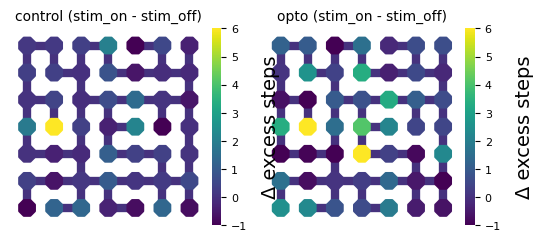

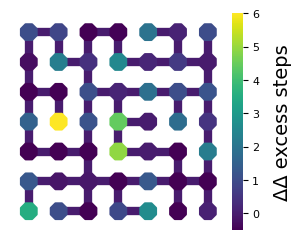

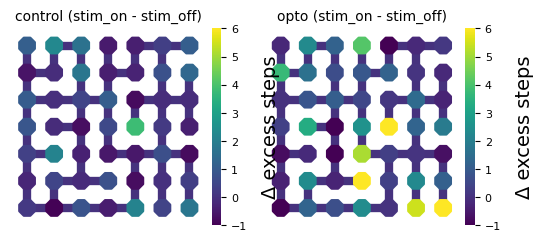

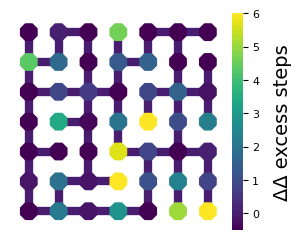

In [19]:
for maze in ["maze_1", "maze_2"]:
    f2, axes2 = plt.subplots(1, 2, figsize=(6, 3))
    f3, axes3 = plt.subplots(1, 1, figsize=(3, 3))
    for pa, v_range, axes in zip(
        ["delta", "delta_delta"],
        [(-1, 6), (-0.5, 6)],
        [axes2, axes3],
    ):
        es.plot_excess_steps_by_goal_heatmap_summary(
            excess_steps_df,
            outlier_thres=200,
            maze_name=maze,
            vmin=v_range[0],
            vmax=v_range[1],
            plot_as=pa,
            colormap="viridis",
            axes=axes,
        )
    f2.savefig(SAVE_FIG_PATH / f"goal_excess_steps_{maze}_{pa}.pdf")
    f3.savefig(SAVE_FIG_PATH / f"goal_excess_steps_{maze}_{pa}_control_opto.pdf")

### Excess steps stratified by goal-graph properties

Within-subject delta excess steps regressed against goal fitness and goal betweenness-centrality to test whether opto-induced impairments scale with goal difficulty.

T-tests on slope from delta xs steps linear fit:
  control vs opto: t(13)=-2.30, p=0.038
  control vs 0: t(7)=0.63, p=0.550
  opto vs 0: t(6)=2.70, p=0.035
T-tests on slope from delta xs steps linear fit:
  control vs opto: t(13)=2.00, p=0.067
  control vs 0: t(7)=-1.41, p=0.200
  opto vs 0: t(6)=-2.97, p=0.025


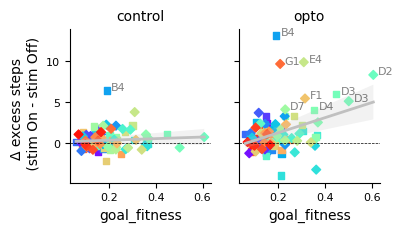

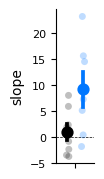

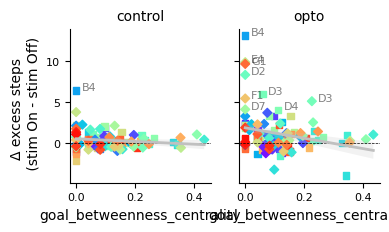

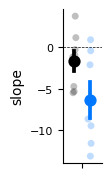

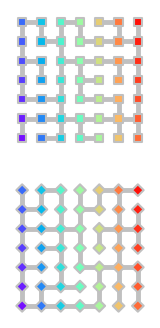

In [20]:
for var in ["goal_fitness", "goal_betweenness_centrality"]:
    f1, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True, sharex=True)
    f2, ax = plt.subplots(1, 1, figsize=(0.5, 2))
    es.plot_stratified_delta_excess_steps(
        excess_steps_df,
        stim_day_range=(6, np.inf),
        outlier_thres=200,
        var=var,
        axes=axes,
    )
    es.plot_delta_excess_steps_fit_slopes(
        excess_steps_df, stim_day_range=(6, np.inf), outlier_thres=200, var=var, print_stats=True, ax=ax
    )
    f1.savefig(SAVE_FIG_PATH / f"goal_excess_steps_stratified_delta_{var}.pdf")
    f2.savefig(SAVE_FIG_PATH / f"goal_excess_steps_stratified_delta_{var}_fit_slopes.pdf")

f, axes = plt.subplots(2, 1, figsize=(2, 4))
es.plot_special_maze_legend(axes=axes)
f.savefig(SAVE_FIG_PATH / "special_maze_legend.pdf")

## On-task behaviour

Cue aligned rate of change of distance to goal highlights on-task behaviour at the start of trials

In [ ]:
from GridMaze.analysis.behaviour import distance_to_goal as dtg

In [22]:
ddtg_df = dtg.get_delta_distance_to_goal_df()

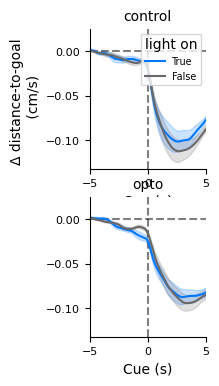

In [23]:
f, axes = plt.subplots(2, 1, figsize=(1.5, 4), sharey=True)
dtg.plot_delta_distance_to_goal_summary(ddtg_df, stim_day_range=(6, np.inf), axes=axes)
f.savefig(SAVE_FIG_PATH / "delta_distance_to_goal.pdf")

## Mixture of strategies modeling

Fit the mixture-of-strategies model (vector, structure, habit, backtracking penalty) to see what strategies are effected by mFC inhibition.

In [3]:
from GridMaze.analysis.strategies import get_input_data as gid
from GridMaze.analysis.strategies import opto_effects as oe

In [4]:
navigation_strategies_df = gid.get_navigation_strategies_df(
    n_history=1,
    verbose=False,
)

Mixed ANOVA: vector
+-------------+------------+-------+-------+------------+----------+-----------+----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |     p-unc |      np2 |   eps |
|-------------+------------+-------+-------+------------+----------+-----------+----------+-------|
| condition   | 0.0190963  |     1 |    13 | 0.0190963  | 1.20267  | 0.292689  | 0.084679 |   nan |
| stim_trial  | 0.0189354  |     1 |    13 | 0.0189354  | 8.70644  | 0.0112574 | 0.401099 |     1 |
| Interaction | 0.00132106 |     1 |    13 | 0.00132106 | 0.607421 | 0.449717  | 0.044639 |   nan |
+-------------+------------+-------+-------+------------+----------+-----------+----------+-------+
Mixed ANOVA: structure
+-------------+------------+-------+-------+------------+-------------+----------+------------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |           F |    p-unc |        np2 |   eps |
|-------------+------------+-------+-------+-----

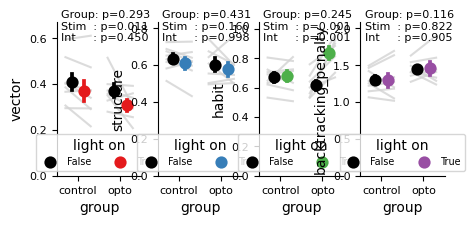

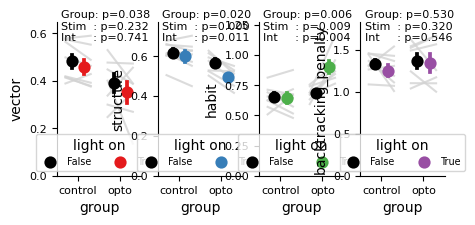

In [28]:
strategies = ["vector", "structure", "habit", "backtracking_penalty"]
for maze in ["maze_1", "maze_2"]:
    fits_df = oe.get_group_by_stim_strategy_weights(
        navigation_strategies_df[navigation_strategies_df.maze_name == maze],
        strategies=strategies,
        stim_day_range=(6, np.inf),
        max_trial_duration=None,
        stim_only=False,
    )
    fig, axes = plt.subplots(1, len(strategies), figsize=(1.25 * len(strategies), 2))
    oe.plot_mixture_of_strategy_weights(fits_df, axes=axes, cmap="Set1", print_stats=True)
    fig.savefig(SAVE_FIG_PATH / f"opto_strategy_weights_{maze}.pdf")

## Movement-speed controls

Tests for non-specific motor effects of mFC inhibition, both during steady-state stimulation and aligned to stim onset and offset.

### Speed profiles aligned to stim onset and offset

Cross-subject speed traces locked to the onset and offset of the light pulse, separated by group.

In [24]:
from GridMaze.analysis.behaviour import movement as mv

stim_on_df = mv.get_aligned_speeds_df(aligned_to="stim_on", verbose=False)
stim_off_df = mv.get_aligned_speeds_df(aligned_to="stim_off", verbose=False)

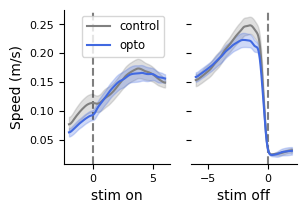

In [25]:
reload(mv)
f, axes = plt.subplots(1, 2, figsize=(3, 2), sharey=True)
mv.plot_stim_aligned_speeds_summary(stim_on_df, stim_off_df, axes=axes)
f.savefig(SAVE_FIG_PATH / "maze_stim_aligned_speeds_summary.pdf")

In [26]:
stim_speeds_df = mv.get_stim_speeds_df()

### Average locomotor speed by stim condition

Per-trial mean running speed compared between stim-on and stim-off trials within subject, to test for gross locomotor effects of inhibition.

Mixed ANOVA: average_speed
+-------------+-------------+-------+-------+-------------+---------+-----------+-----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |       F |     p-unc |       np2 |   eps |
|-------------+-------------+-------+-------+-------------+---------+-----------+-----------+-------|
| condition   | 0.00114144  |     1 |    13 | 0.00114144  | 0.49026 | 0.496152  | 0.0363418 |   nan |
| stim_trial  | 0.0002014   |     1 |    13 | 0.0002014   | 3.53786 | 0.0825694 | 0.213925  |     1 |
| Interaction | 0.000431709 |     1 |    13 | 0.000431709 | 7.58355 | 0.0164174 | 0.368428  |   nan |
+-------------+-------------+-------+-------+-------------+---------+-----------+-----------+-------+


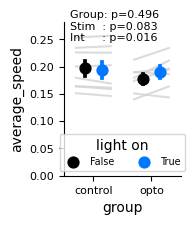

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 2))
mv.plot_stim_speeds_summary(stim_speeds_df, stim_day_range=(6, np.inf), ax=ax)
fig.savefig(SAVE_FIG_PATH / "maze_stim_speeds_summary.pdf")